Data Loaded Successfully!
   row_id        order_id  order_date   ship_date       ship_mode customer_id  \
0       1  ca-2017-152156  2017-08-11  2017-11-11    Second Class    CG-12520   
1       2  ca-2017-152156  2017-08-11  2017-11-11    Second Class    CG-12520   
2      14  ca-2017-161389  2017-05-12  2017-10-12  Standard Class    IM-15070   
3      36  ca-2017-117590  2017-08-12  2017-10-12     First Class    GH-14485   
4      37  ca-2017-117590  2017-08-12  2017-10-12     First Class    GH-14485   

  customer_name    segment        country        city       state  \
0   claire gute   Consumer  United States   Henderson    Kentucky   
1   claire gute   Consumer  United States   Henderson    Kentucky   
2  irene maddox   Consumer  United States     Seattle  Washington   
3     gene hale  Corporate  United States  Richardson       Texas   
4     gene hale  Corporate  United States  Richardson       Texas   

   postal_code   region       product_id         category sub-category  

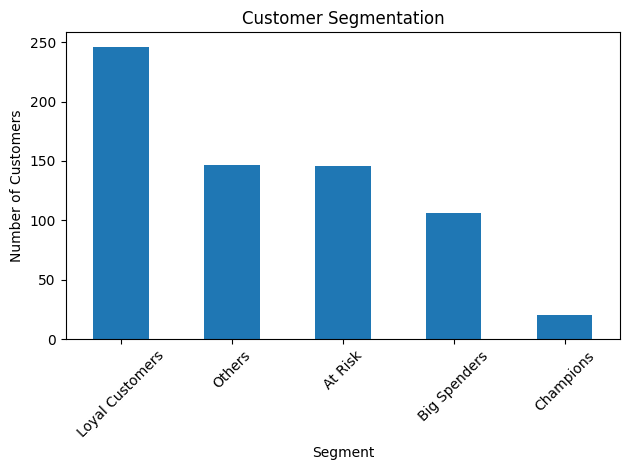


✅ RFM Analysis Completed & File Saved!


In [11]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("C:/Users/vishn/OneDrive/Desktop/Cleaned_DataSet.csv")

print("Data Loaded Successfully!")
print(df.head())

# ==============================
# 2. DATA PREPROCESSING
# ==============================

# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Check missing values
df = df.dropna(subset=['customer_id'])

# ==============================
# 3. CREATE REFERENCE DATE
# ==============================

reference_date = df['order_date'].max() + timedelta(days=1)

# ==============================
# 4. CALCULATE RFM
# ==============================

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                   # Frequency
    'sales': 'sum'                                           # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("\nRFM Table:")
print(rfm.head())

# ==============================
# 5. CREATE RFM SCORES (1–5)
# ==============================

# Recency (lower is better)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency (higher is better)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary (higher is better)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# ==============================
# 6. FINAL RFM SCORE
# ==============================

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + \
                   rfm['F_Score'].astype(str) + \
                   rfm['M_Score'].astype(str)

print("\nRFM Scores:")
print(rfm.head())

# ==============================
# 7. CUSTOMER SEGMENTATION
# ==============================

def segment_customer(row):
    if row['R_Score'] == 5 and row['F_Score'] == 5 and row['M_Score'] == 5:
        return 'Champions'
    elif row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['M_Score'] >= 4:
        return 'Big Spenders'
    elif row['R_Score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

# ==============================
# 8. BUSINESS INSIGHTS
# ==============================

# Revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
print("\nRevenue by Segment:")
print(segment_revenue)

# ==============================
# 9. VISUALIZATION
# ==============================

rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 10. SAVE csv File (FOR POWER BI)
# ==============================

rfm.to_csv("RFM_Output.csv")

print("\n✅ RFM Analysis Completed & File Saved!")